**Importing Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

**Loading Dataset**

In [2]:
df = pd.read_csv("drug200.csv")

print(df.head())
print(df.shape)

   Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  drugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  drugY
(200, 6)


**Selecting Numerical Features**

In [3]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

print(numeric_df.head())

   Age  Na_to_K
0   23   25.355
1   47   13.093
2   47   10.114
3   28    7.798
4   61   18.043


**Standardize Data**

In [4]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

**Applying PCA**

In [5]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

print(pca_result[:5])

[[-1.82300128 -0.00358425]
 [ 0.40859745 -0.1785068 ]
 [ 0.70092443 -0.47083378]
 [ 0.11409074 -1.51220207]
 [ 0.52272164  0.90709678]]


**Applying K-Means Clustering**

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(pca_result)

**Visualizing Clusters**

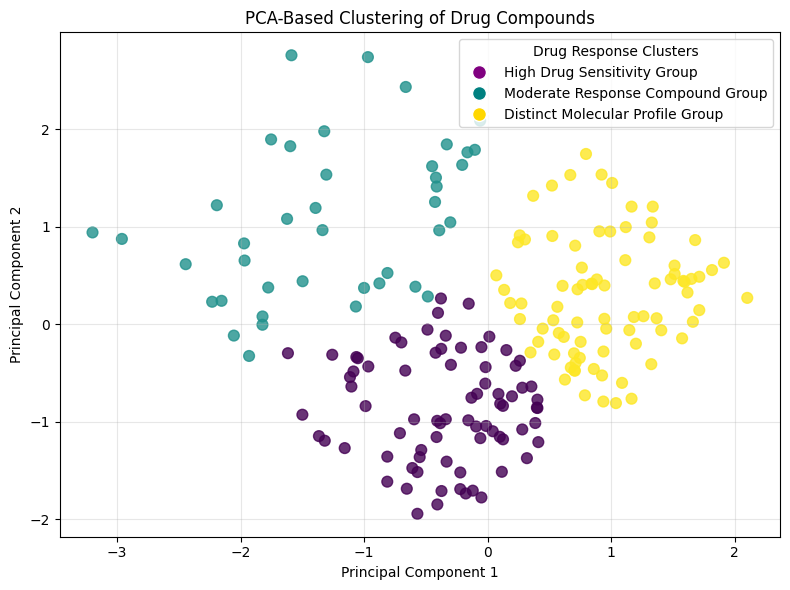

In [14]:
plt.figure(figsize=(8,6))

# Scatter plot
scatter = plt.scatter(
    pca_result[:,0],
    pca_result[:,1],
    c=clusters,
    s=60,
    alpha=0.8
)

# Title and labels
plt.title("PCA-Based Clustering of Drug Compounds")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Custom informative legend
plt.legend(
    handles=[
        plt.Line2D(
            [], [],
            marker='o',
            color='w',
            markerfacecolor='purple',
            markersize=10,
            label='High Drug Sensitivity Group'
        ),

        plt.Line2D(
            [], [],
            marker='o',
            color='w',
            markerfacecolor='teal',
            markersize=10,
            label='Moderate Response Compound Group'
        ),

        plt.Line2D(
            [], [],
            marker='o',
            color='w',
            markerfacecolor='gold',
            markersize=10,
            label='Distinct Molecular Profile Group'
        )
    ],

    title="Drug Response Clusters",
    loc="best"
)

# Grid
plt.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

# Show graph
plt.show()